In [1]:
import torch, torch.nn as nn
import transformers, peft
from transformers import AutoConfig, AutoModel, AutoModelForCausalLM, AutoModelForSequenceClassification, PreTrainedTokenizerFast
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

print("transformers:", transformers.__version__, "| peft:", peft.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Rebuild the same offline tokenizer + tiny BERT config from Part 1 (self-contained, no need to re-run Part 1)
corpus = [
    "AlfredX is an AI voice assistant built with PyQt5 and FastAPI.",
    "The assistant uses the Groq API and Ollama for language understanding.",
    "It supports over one hundred voice and text commands.",
    "Transformers use self-attention to process sequences in parallel.",
    "Fine-tuning adapts a pretrained model to a new, smaller dataset.",
    "LoRA freezes the base model and trains small adapter matrices instead.",
]
tok = Tokenizer(models.BPE(unk_token="[UNK]"))
tok.pre_tokenizer = pre_tokenizers.Whitespace()
trainer = trainers.BpeTrainer(vocab_size=300, special_tokens=["[UNK]","[PAD]","[CLS]","[SEP]","[MASK]"])
tok.train_from_iterator(corpus, trainer)
hf_tok = PreTrainedTokenizerFast(tokenizer_object=tok, unk_token="[UNK]", pad_token="[PAD]",
                                 cls_token="[CLS]", sep_token="[SEP]", mask_token="[MASK]")

bert_config = AutoConfig.for_model("bert", vocab_size=hf_tok.vocab_size, hidden_size=64,
                                   num_hidden_layers=2, num_attention_heads=4,
                                   intermediate_size=128, max_position_embeddings=32)
bert_config.num_labels = 2
print("Ready. Vocab size:", hf_tok.vocab_size)

transformers: 5.17.0 | peft: 0.21.1
device: cpu
Ready. Vocab size: 209


In [2]:
# --- Example 1: apply LoRA to our offline tiny BERT and see the trainable-param drop ---
from peft import LoraConfig, get_peft_model, TaskType

base_model = AutoModelForSequenceClassification.from_config(bert_config)
total_before = sum(p.numel() for p in base_model.parameters())
trainable_before = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
print(f"Before LoRA -> total: {total_before:,} | trainable: {trainable_before:,} (100%)")

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8, lora_alpha=16, lora_dropout=0.1,
    target_modules=["query", "value"],   # BERT's attention projections
)
peft_model = get_peft_model(base_model, lora_config)
peft_model.print_trainable_parameters()

Before LoRA -> total: 86,914 | trainable: 86,914 (100%)
trainable params: 4,226 || all params: 91,140 || trainable%: 4.6368


In [3]:
# --- Example 2: inspect exactly what became trainable ---
for name, p in peft_model.named_parameters():
    if p.requires_grad:
        print(name, tuple(p.shape))

base_model.model.bert.encoder.layer.0.attention.self.query.lora_A.default.weight (8, 64)
base_model.model.bert.encoder.layer.0.attention.self.query.lora_B.default.weight (64, 8)
base_model.model.bert.encoder.layer.0.attention.self.value.lora_A.default.weight (8, 64)
base_model.model.bert.encoder.layer.0.attention.self.value.lora_B.default.weight (64, 8)
base_model.model.bert.encoder.layer.1.attention.self.query.lora_A.default.weight (8, 64)
base_model.model.bert.encoder.layer.1.attention.self.query.lora_B.default.weight (64, 8)
base_model.model.bert.encoder.layer.1.attention.self.value.lora_A.default.weight (8, 64)
base_model.model.bert.encoder.layer.1.attention.self.value.lora_B.default.weight (64, 8)
base_model.model.classifier.modules_to_save.default.weight (2, 64)
base_model.model.classifier.modules_to_save.default.bias (2,)


In [4]:
# --- Example 3: a real (tiny) LoRA training run, using the same Trainer pattern from Part 1 ---
from datasets import Dataset
from transformers import TrainingArguments, Trainer
import numpy as np

texts  = ["AlfredX handles reminders well.", "The bug caused constant crashes.",
         "Streaming responses feel smooth.", "Missing history was a major bug.",
         "The HUD looks great on screen.", "Broken context handling frustrated users."]
labels = [1, 0, 1, 0, 1, 0]
ds = Dataset.from_dict({"text": texts, "label": labels})
ds = ds.map(lambda b: hf_tok(b["text"], padding="max_length", truncation=True, max_length=16), batched=True)
ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

args = TrainingArguments(output_dir="hf_lora_out", num_train_epochs=6, per_device_train_batch_size=3,
                         logging_strategy="epoch", save_strategy="no", report_to=[], learning_rate=1e-3)
trainer = Trainer(model=peft_model, args=args, train_dataset=ds)
trainer.train()

Map:   0%|          | 0/6 [00:00<?, ? examples/s]

c:\Users\fragr\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
2,0.695557
4,0.694757
6,0.690838
8,0.693046
10,0.693146
12,0.692059


TrainOutput(global_step=12, training_loss=0.6932336787382761, metrics={'train_runtime': 0.5164, 'train_samples_per_second': 69.72, 'train_steps_per_second': 23.24, 'total_flos': 261232128.0, 'train_loss': 0.6932336787382761, 'epoch': 6.0})

In [5]:
# --- Example 1: dynamic quantization on our offline model (real, runs now, CPU) ---
import os

fp32_model = AutoModel.from_config(bert_config)
fp32_size = sum(p.numel() * p.element_size() for p in fp32_model.parameters())

quantized = torch.quantization.quantize_dynamic(fp32_model, {nn.Linear}, dtype=torch.qint8)

torch.save(fp32_model.state_dict(), "fp32_temp.pt")
torch.save(quantized.state_dict(), "int8_temp.pt")
print(f"FP32 file size: {os.path.getsize('fp32_temp.pt')/1024:.1f} KB")
print(f"INT8 file size: {os.path.getsize('int8_temp.pt')/1024:.1f} KB")
os.remove("fp32_temp.pt"); os.remove("int8_temp.pt")

FP32 file size: 354.0 KB
INT8 file size: 159.8 KB


C:\Users\fragr\AppData\Local\Temp\ipykernel_20000\1534152018.py:7: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized = torch.quantization.quantize_dynamic(fp32_model, {nn.Linear}, dtype=torch.qint8)
c:\Users\fragr\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\ao\nn\quantized\modules\utils.py:72: UserWarning: torch.quantize_per_tensor, torch.quanti

In [6]:
# --- Example 2: confirm it still runs and compare outputs ---
enc = hf_tok("AlfredX is an AI voice assistant.", return_tensors="pt", padding="max_length", max_length=16, truncation=True)
with torch.no_grad():
    out_fp32 = fp32_model(**enc).last_hidden_state
    out_int8 = quantized(**enc).last_hidden_state

print("Shapes match:", out_fp32.shape == out_int8.shape)
print("Max output difference:", (out_fp32 - out_int8).abs().max().item())   # small, not zero -- that's the quantization tradeoff

Shapes match: True
Max output difference: 2.6310219764709473


In [7]:
# --- Example 1: a tiny CausalLM (GPT-style) built offline via from_config, run through generate() ---
gpt_config = AutoConfig.for_model("gpt2", vocab_size=hf_tok.vocab_size, n_embd=64, n_layer=2, n_head=4, n_positions=32)
gpt = AutoModelForCausalLM.from_config(gpt_config)

prompt_ids = hf_tok("AlfredX is", return_tensors="pt")["input_ids"]

greedy_out = gpt.generate(prompt_ids, max_new_tokens=10, do_sample=False)
print("Greedy       :", hf_tok.decode(greedy_out[0]))

beam_out = gpt.generate(prompt_ids, max_new_tokens=10, num_beams=4, do_sample=False)
print("Beam search  :", hf_tok.decode(beam_out[0]))

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 208), got 50256. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 208), got 50256. This may result in unexpected behavior.


Greedy       : AlfredX is is is is is is is is is is is
Beam search  : AlfredX is x x x x x x x x x x


In [8]:
# --- Example 2: sampling strategies (note: random weights -> gibberish text, but the API + effect of each knob is real) ---
torch.manual_seed(0)
topk_out = gpt.generate(prompt_ids, max_new_tokens=10, do_sample=True, top_k=20, temperature=0.8)
print("Top-k sample :", hf_tok.decode(topk_out[0]))

topp_out = gpt.generate(prompt_ids, max_new_tokens=10, do_sample=True, top_p=0.9, temperature=0.8)
print("Top-p sample :", hf_tok.decode(topp_out[0]))

# temperature comparison -- same prompt, low vs high randomness
torch.manual_seed(0)
low_temp  = gpt.generate(prompt_ids, max_new_tokens=10, do_sample=True, temperature=0.3)
torch.manual_seed(0)
high_temp = gpt.generate(prompt_ids, max_new_tokens=10, do_sample=True, temperature=1.5)
print("Low temp (0.3) :", hf_tok.decode(low_temp[0]))
print("High temp (1.5):", hf_tok.decode(high_temp[0]))

Top-k sample : AlfredX is mo [SEP] tun gu e e freez Oll m attention
Top-p sample : AlfredX is mm O tun small sequ age mm language mers en
Low temp (0.3) : AlfredX is trice [SEP] and Qt uses process es Lo matrices attention
High temp (1.5): AlfredX is trice [SEP] and Qt uses process es Lo matrices attention


In [9]:
# --- Example 3: other common generate() controls ---
out = gpt.generate(
    prompt_ids, max_new_tokens=15,
    do_sample=True, top_k=50, top_p=0.9, temperature=0.8,
    repetition_penalty=1.2,     # >1.0 discourages repeating tokens
    no_repeat_ngram_size=2,     # never repeat the same 2-token sequence
    num_return_sequences=2,     # generate multiple candidates at once
    pad_token_id=hf_tok.pad_token_id,
)
for i, seq in enumerate(out):
    print(f"candidate {i}:", hf_tok.decode(seq))

candidate 0: AlfredX is mo he u [CLS] ead bu red und red ad ap ex y anding sfor
candidate 1: AlfredX is to anding oice at rice A Qt und assist ll Ollama w pp ences u


In [10]:
# --- Example 1: save model + tokenizer together, locally (fully offline, real) ---
save_dir = "my_saved_model"
fp32_model.save_pretrained(save_dir)
hf_tok.save_pretrained(save_dir)

import os
print("Saved files:", os.listdir(save_dir))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved files: ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


In [11]:
# --- Example 2: load back exactly like a Hub model -- from_pretrained works on local folders too ---
reloaded_model = AutoModel.from_pretrained(save_dir)
reloaded_tok = PreTrainedTokenizerFast.from_pretrained(save_dir)

enc = reloaded_tok("AlfredX works offline.", return_tensors="pt")
with torch.no_grad():
    out = reloaded_model(**enc)
print("Reloaded model output shape:", out.last_hidden_state.shape)

import shutil; shutil.rmtree(save_dir)   # cleanup

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

Reloaded model output shape: torch.Size([1, 11, 64])


In [16]:
import os
import torch
import onnxruntime as ort

dummy = hf_tok("AlfredX export test.", return_tensors="pt", padding="max_length", max_length=16, truncation=True)
fp32_model.eval()

# Export the MODEL directly, not a wrapper function
torch.onnx.export(
    fp32_model,  # Pass the model, not model_wrapper
    args=(dummy["input_ids"], dummy["attention_mask"]),
    f="model.onnx",
    input_names=["input_ids", "attention_mask"],
    output_names=["last_hidden_state"],
    dynamic_axes={"input_ids": {0: "batch"}, "attention_mask": {0: "batch"}},
    opset_version=14,
)

print("Exported: model.onnx (", round(os.path.getsize("model.onnx")/1024, 1), "KB )")

session = ort.InferenceSession("model.onnx")
onnx_out = session.run(None, {"input_ids": dummy["input_ids"].numpy(), "attention_mask": dummy["attention_mask"].numpy()})

with torch.no_grad():
    torch_out = fp32_model(**dummy).last_hidden_state.numpy()

print("ONNX output shape :", onnx_out[0].shape)
print("Max diff vs PyTorch:", abs(onnx_out[0] - torch_out).max())
os.remove("model.onnx")

C:\Users\fragr\AppData\Local\Temp\ipykernel_20000\2363901999.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0930 14:49:42.233000 20000 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `BertModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BertModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 14).


[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 14 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\fragr\AppData\Local\Programs\Python\Python310\lib\site-packages\onnxscript\version_converter\__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
  File "c:\Users\fragr\AppData\Local\Programs\Python\Python310\lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "c:\Users\fragr\AppData\Local\Programs\Python\Python310\lib\site-packages\onnxscript\version_converter\__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
  File "c:\Users\fragr\AppData\Local\Programs\Python\Python310\lib\site-packages\onnx\version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
RuntimeError: D:\a\onnx\onnx\onnx/version_converter/adapters/no_previou

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported: model.onnx ( 240.1 KB )
ONNX output shape : (1, 16, 64)
Max diff vs PyTorch: 9.536743e-07


In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1) Slightly bigger offline dataset
texts = [
    "AlfredX handles reminders and timers well.", "The rate-limit retry logic keeps the app stable.",
    "The bug caused the app to crash randomly.", "Broken context handling frustrated users.",
    "The bilingual interface is a nice touch.", "Streaming responses feel fast and smooth.",
    "The duplicate class definition caused confusing errors.", "Missing conversation history was a major bug.",
    "The JARVIS-style HUD looks great on screen.", "The WebSocket companion app works reliably.",
    "Voice recognition sometimes misheard commands.", "The wake word detection is fast and accurate.",
    "Documentation setup was confusing at first.", "The GitHub README made setup painless.",
]
labels = [1,1,0,0,1,1,0,0,1,1,0,1,0,1]

ds = Dataset.from_dict({"text": texts, "label": labels})
ds = ds.map(lambda b: hf_tok(b["text"], padding="max_length", truncation=True, max_length=20), batched=True)
split = ds.train_test_split(test_size=0.3, seed=42)
split.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
print(split)

Map:   0%|          | 0/14 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 9
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 5
    })
})


In [18]:
# 2) Fresh base model + LoRA adapter
base = AutoModelForSequenceClassification.from_config(bert_config)
lora_cfg = LoraConfig(task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.1, target_modules=["query", "value"])
proj_model = get_peft_model(base, lora_cfg)
proj_model.print_trainable_parameters()

trainable params: 4,226 || all params: 91,140 || trainable%: 4.6368


In [19]:
# 3) Train
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": (preds == labels).mean()}

args = TrainingArguments(output_dir="hf_mini_out", num_train_epochs=10, per_device_train_batch_size=4,
                         per_device_eval_batch_size=4, eval_strategy="epoch", save_strategy="no",
                         logging_strategy="epoch", learning_rate=1e-3, report_to=[])

proj_trainer = Trainer(model=proj_model, args=args, train_dataset=split["train"],
                       eval_dataset=split["test"], compute_metrics=compute_metrics)
proj_trainer.train()

c:\Users\fragr\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.694875,0.691743,0.600000
2,0.686132,0.694650,0.600000
3,0.688383,0.697090,0.200000
4,0.690634,0.698361,0.200000
5,0.671417,0.699121,0.200000
6,0.666666,0.700187,0.400000
7,0.660683,0.701190,0.400000
8,0.665085,0.702045,0.400000
9,0.675192,0.702669,0.400000
10,0.668389,0.702911,0.400000


TrainOutput(global_step=30, training_loss=0.6767457445462545, metrics={'train_runtime': 1.4099, 'train_samples_per_second': 63.836, 'train_steps_per_second': 21.279, 'total_flos': 816350400.0, 'train_loss': 0.6767457445462545, 'epoch': 10.0})

c:\Users\fragr\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fragr\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fragr\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         3
    positive       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg       0.20      0.50      0.29         5
weighted avg       0.16      0.40      0.23         5



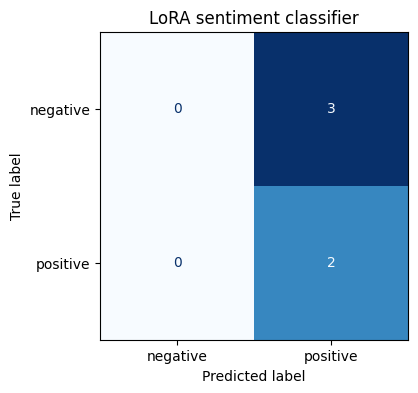

In [20]:
# 4) Evaluate
preds = proj_trainer.predict(split["test"])
pred_labels = np.argmax(preds.predictions, axis=1)
print(classification_report(preds.label_ids, pred_labels, target_names=["negative", "positive"]))

cm = confusion_matrix(preds.label_ids, pred_labels)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["negative", "positive"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("LoRA sentiment classifier"); plt.show()

In [21]:
# 5) Save the LoRA adapter (tiny file -- this is the whole point of PEFT)
proj_model.save_pretrained("lora_adapter")
print("Adapter files:", os.listdir("lora_adapter"))
print("Adapter size:", sum(os.path.getsize(f"lora_adapter/{f}") for f in os.listdir("lora_adapter")) / 1024, "KB")
# Compare: the full base model has far more parameters saved -- the adapter alone is a small fraction of that.
import shutil; shutil.rmtree("lora_adapter")

Adapter files: ['adapter_config.json', 'adapter_model.safetensors', 'README.md']
Adapter size: 23.916015625 KB
